In [1]:
import os
import cv2
import albumentations as A
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import numpy as np
import random
import matplotlib.pyplot as plt
import glob
import shutil
import datetime
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

C:\Users\chail\anaconda3\envs\tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
datasets = [
    ("swinseg/images", "swinseg/GTmaps"),
    ("swimseg/images", "swimseg/GTmaps"),
]
TCDD_dataset = [("TCDD/train/images","TCDD/train/labels")]
output_dir = "dataset"

splits = ["train", "val", "test"]

for s in splits:
    os.makedirs(f"{output_dir}/{s}/images", exist_ok=True)
    os.makedirs(f"{output_dir}/{s}/labels", exist_ok=True)

pairs = []

for img_dir, mask_dir in datasets:
    prefix = img_dir.split('/')[0]

    if not os.path.exists(img_dir):
        print(f"Warning: Directory {img_dir} not found. Skipping.")
        continue

    images = os.listdir(img_dir)

    for img in images:
        name, ext = os.path.splitext(img)
        mask_name = name + "_GT" + ext
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            prefixed_name = f"{prefix}_{img}"
            
            pairs.append((
                os.path.normpath(os.path.join(img_dir, img)),
                os.path.normpath(mask_path),
                prefixed_name
            ))
for img_dir, mask_dir in TCDD_dataset:
    prefix = img_dir.split('/')[0]

    if not os.path.exists(img_dir):
        print(f"Warning: Directory {img_dir} not found. Skipping.")
        continue

    images = os.listdir(img_dir)

    for img in images:
        name, ext = os.path.splitext(img)
        mask_path = os.path.join(mask_dir, img)

        if os.path.exists(mask_path):
            prefixed_name = f"{prefix}_{img}"
            
            pairs.append((
                os.path.normpath(os.path.join(img_dir, img)),
                os.path.normpath(mask_path),
                prefixed_name
            ))
print("Total pairs:", len(pairs))

random.shuffle(pairs)

train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

def copy_pairs(pairs, split):
    for img_path, mask_path, name in pairs:
        shutil.copy(img_path, f"{output_dir}/{split}/images/{name}")
        shutil.copy(mask_path, f"{output_dir}/{split}/labels/{name}")

copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")
copy_pairs(test_pairs, "test")

print("Dataset creation finished!")

In [5]:
IMG_SIZE = 300
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=30,
        border_mode=0,
        p=0.7
    ),

], additional_targets={"mask": "mask"})
output_dir="dataset"

def load_paths(split):

    img_dir = os.path.join(output_dir, split, "images")
    mask_dir = os.path.join(output_dir, split, "labels")

    img_paths = []
    mask_paths = []

    mask_files = os.listdir(mask_dir)

    mask_dict = {}
    for m in mask_files:
        name = os.path.splitext(m)[0]
        mask_dict[name] = os.path.join(mask_dir, m)

    for img_name in os.listdir(img_dir):

        name = os.path.splitext(img_name)[0]
        img_path = os.path.join(img_dir, img_name)

        if name in mask_dict:
            img_paths.append(img_path)
            mask_paths.append(mask_dict[name])
        else:
            print("No mask for:", img_name)

    return img_paths, mask_paths

def augment_fn(image, mask):
    augmented = transform(image=image, mask=mask)

    image = augmented["image"]
    mask = augmented["mask"]

    return image.astype("float32"), mask.astype("float32")

def load_image_mask(img_path, mask_path, augment=False):

    image = tf.io.read_file(img_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")

    image = tf.cast(image, tf.float32) / 255.0
    mask = tf.cast(mask > 127, tf.float32)

    if augment:
        image, mask = tf.numpy_function(
            func=augment_fn,
            inp=[image, mask],
            Tout=[tf.float32, tf.float32]
        )
        image.set_shape((IMG_SIZE, IMG_SIZE, 3))
        mask.set_shape((IMG_SIZE, IMG_SIZE, 1))

    return image, mask

def create_dataset(img_paths, mask_paths, batch_size=4, shuffle=True, augment=False):

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    dataset = dataset.map(lambda x, y: load_image_mask(x, y, augment),
                          num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(img_paths))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [7]:
train_img, train_mask = load_paths("train")
val_img, val_mask = load_paths("val")
test_img, test_mask = load_paths("test")

train_dataset = create_dataset(train_img, train_mask, batch_size=16, shuffle=True,augment=True)
val_dataset = create_dataset(val_img, val_mask, batch_size=16, shuffle=False)
test_dataset = create_dataset(test_img, test_mask, batch_size=16, shuffle=False)

In [8]:
def build_model(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)

    # ========== Encoder ==========
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # ========== Decoder ==========
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(16, (3, 3), activation='relu', padding='valid')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoded = layers.Conv2D(1, (5, 5), activation='sigmoid', padding='same')(x)

    model = Model(inputs, decoded, name="CloudSegNet")
    return model


In [6]:
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adadelta(learning_rate=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cloudsegnet_v2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)
start_time = datetime.datetime.now()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=300,
    callbacks=[checkpoint]
)
end_time = datetime.datetime.now()
period = end_time-start_time
print(f'Training time: {period.total_seconds():.2f} seconds')

Epoch 1/300
132/132 [==============================] - 19s 68ms/step - loss: 0.5244 - accuracy: 0.7605 - val_loss: 0.4914 - val_accuracy: 0.7984
Epoch 2/300
132/132 [==============================] - 10s 63ms/step - loss: 0.4143 - accuracy: 0.8125 - val_loss: 0.5740 - val_accuracy: 0.7403
Epoch 3/300
132/132 [==============================] - 11s 67ms/step - loss: 0.4042 - accuracy: 0.8173 - val_loss: 0.5379 - val_accuracy: 0.7290
Epoch 4/300
132/132 [==============================] - 11s 67ms/step - loss: 0.3941 - accuracy: 0.8232 - val_loss: 0.4035 - val_accuracy: 0.8239
Epoch 5/300
132/132 [==============================] - 11s 65ms/step - loss: 0.3807 - accuracy: 0.8309 - val_loss: 0.4585 - val_accuracy: 0.7960
Epoch 6/300
132/132 [==============================] - 11s 66ms/step - loss: 0.3686 - accuracy: 0.8351 - val_loss: 0.4001 - val_accuracy: 0.8283
Epoch 7/300
132/132 [==============================] - 11s 64ms/step - loss: 0.3634 - accuracy: 0.8385 - val_loss: 0.3838 - val_ac

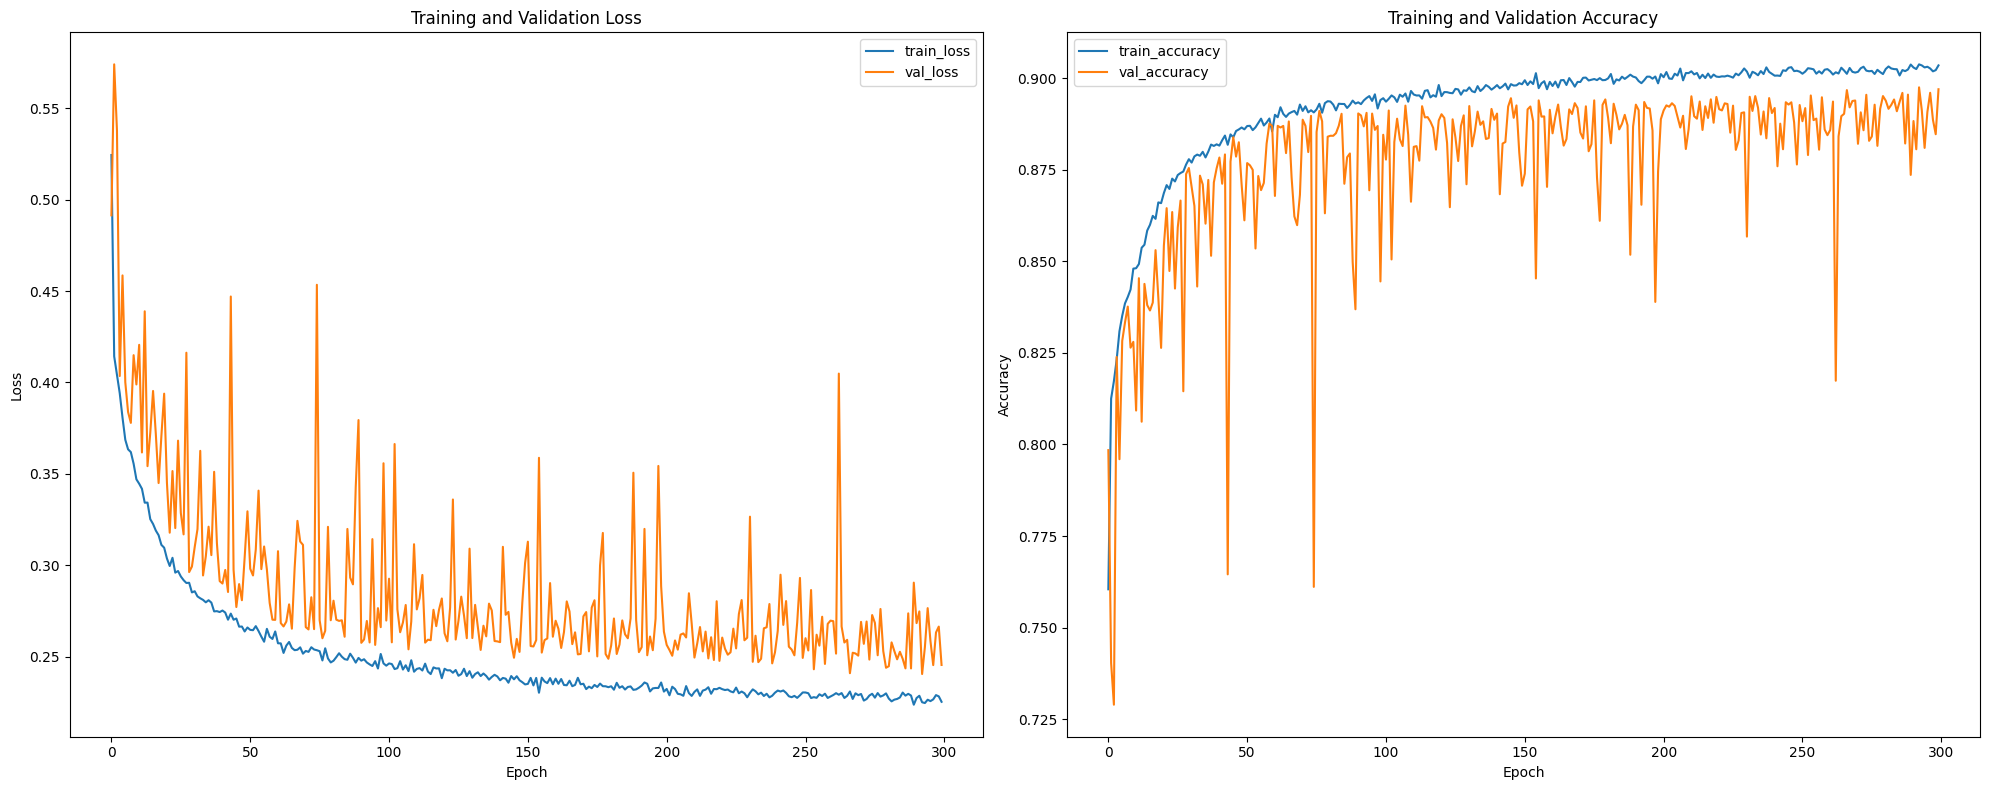

In [7]:
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
train_acc = history.history['accuracy']
plt.figure(figsize=(20, 8))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['train_loss', 'val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')


plt.subplot(1, 2, 2)
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['train_accuracy', 'val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig("training_performance.png", dpi=500)
plt.show()

In [11]:
best_model = load_model(
    'best_cloudsegnet.keras'
)

In [9]:
y_true_all = []
y_pred_all = []

for images, masks in val_dataset:   
    preds = best_model.predict(images, verbose=0)
    y_true_all.append(masks.numpy())
    y_pred_all.append(preds)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

y_true_bin = (y_true_all > 0.5).astype(np.uint8)

thresholds = np.arange(0.1, 0.91, 0.05)

best_threshold = None
best_iou = -1
results = []

for t in thresholds:
    y_pred_bin = (y_pred_all > t).astype(np.uint8)

    y_true_flat = y_true_bin.reshape(-1)
    y_pred_flat = y_pred_bin.reshape(-1)

    # IoU
    intersection = np.sum((y_true_flat == 1) & (y_pred_flat == 1))
    union = np.sum((y_true_flat == 1) | (y_pred_flat == 1))
    iou = intersection / union if union != 0 else 0

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    results.append((t, iou, precision, recall, f1))

    if iou > best_iou:
        best_iou = iou
        best_threshold = t

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best IoU: {best_iou:.4f}")

print("\nAll results:")
for t, iou, precision, recall, f1 in results:
    print(f"Threshold={t:.2f} | IoU={iou:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}")

Best threshold: 0.45
Best IoU: 0.8295

All results:
Threshold=0.10 | IoU=0.7753 | Precision=0.7862 | Recall=0.9825 | F1=0.8734
Threshold=0.15 | IoU=0.7943 | Precision=0.8111 | Recall=0.9746 | F1=0.8854
Threshold=0.20 | IoU=0.8078 | Precision=0.8309 | Recall=0.9666 | F1=0.8937
Threshold=0.25 | IoU=0.8171 | Precision=0.8475 | Recall=0.9579 | F1=0.8993
Threshold=0.30 | IoU=0.8232 | Precision=0.8618 | Recall=0.9485 | F1=0.9030
Threshold=0.35 | IoU=0.8271 | Precision=0.8742 | Recall=0.9389 | F1=0.9054
Threshold=0.40 | IoU=0.8292 | Precision=0.8852 | Recall=0.9291 | F1=0.9066
Threshold=0.45 | IoU=0.8295 | Precision=0.8953 | Recall=0.9186 | F1=0.9068
Threshold=0.50 | IoU=0.8283 | Precision=0.9051 | Recall=0.9071 | F1=0.9061
Threshold=0.55 | IoU=0.8255 | Precision=0.9149 | Recall=0.8942 | F1=0.9044
Threshold=0.60 | IoU=0.8205 | Precision=0.9246 | Recall=0.8794 | F1=0.9014
Threshold=0.65 | IoU=0.8131 | Precision=0.9341 | Recall=0.8625 | F1=0.8969
Threshold=0.70 | IoU=0.8024 | Precision=0.9433 |

1/1 [==============================] - 0s 123ms/step
              precision    recall  f1-score   support

  Background     0.8910    0.8589    0.8747  17565866
       Cloud     0.8953    0.9199    0.9074  23024134

    accuracy                         0.8935  40590000
   macro avg     0.8932    0.8894    0.8910  40590000
weighted avg     0.8934    0.8935    0.8932  40590000



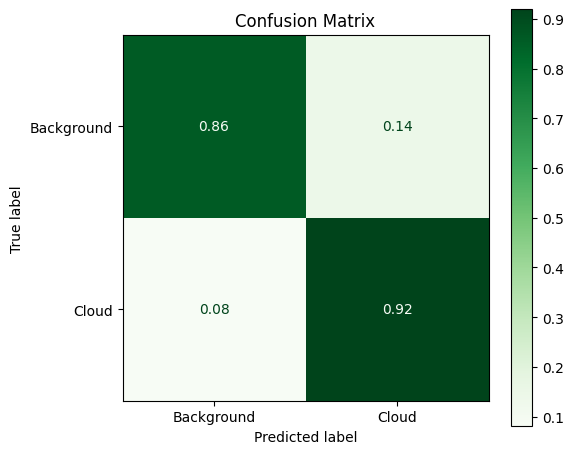

In [12]:
y_true_all = []
y_pred_all = []
x_test_all = []

for images, masks in test_dataset:
    preds = best_model.predict(images)

    x_test_all.append(images.numpy())
    y_true_all.append(masks.numpy())
    y_pred_all.append(preds)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)
x_test_all = np.concatenate(x_test_all, axis=0)

y_pred_bin = (y_pred_all > 0.45).astype(np.uint8)
y_true_bin = (y_true_all > 0.45).astype(np.uint8)

y_true_flat = y_true_bin.reshape(-1)
y_pred_flat = y_pred_bin.reshape(-1)

print(classification_report(
    y_true_flat,
    y_pred_flat,
    target_names=["Background", "Cloud"],
    digits = 4
))

cm = confusion_matrix(y_true_flat, y_pred_flat, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Cloud"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='.2f', cmap='Greens')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=500)
plt.show()



In [11]:
cm = confusion_matrix(y_true_flat, y_pred_flat)
TP = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

iou = TP / (TP + FP + FN)
print(f"Cloud IoU: {iou:.4f}")

Cloud IoU: 0.8305


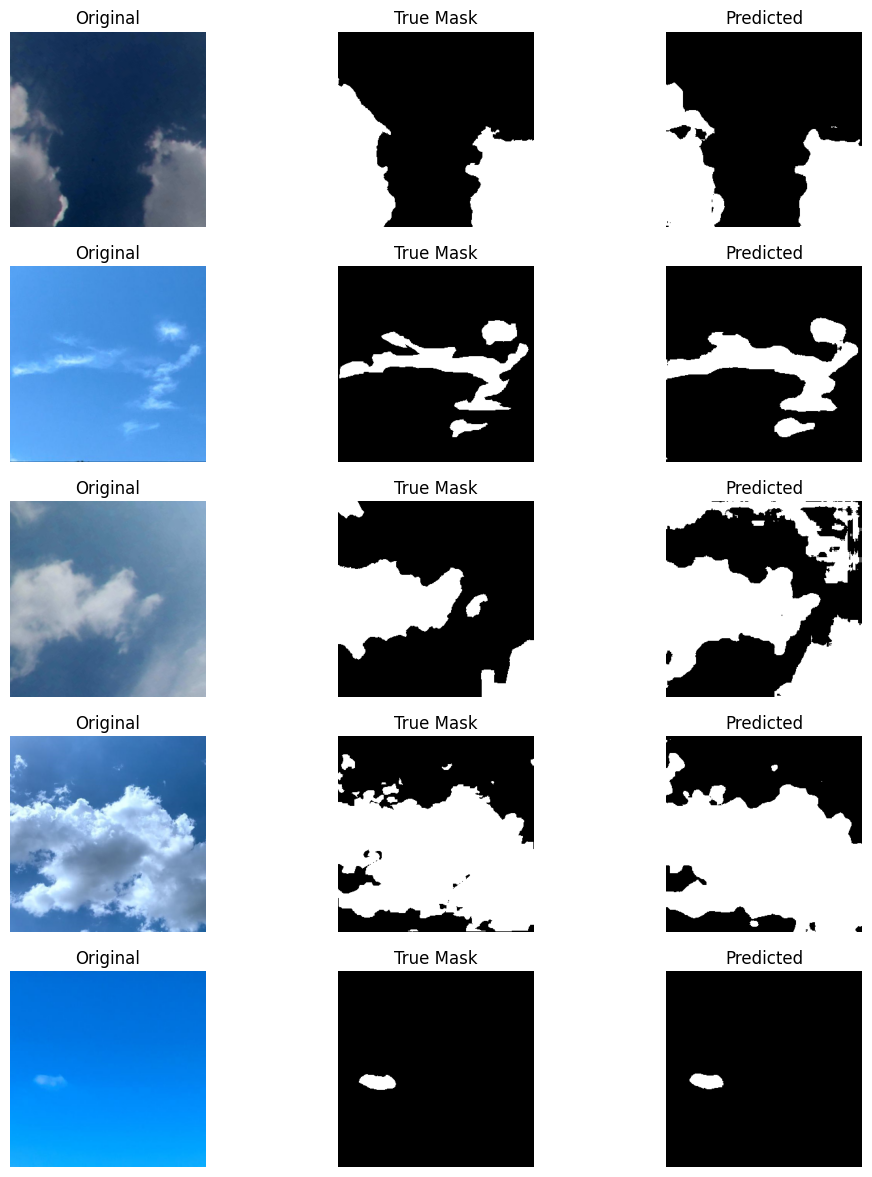

In [14]:
threshold = 0.45
min_area = 1000

indices = random.sample(range(len(x_test_all)), 5)

plt.figure(figsize=(12, 30))

for idx_i, idx in enumerate(indices):

    image = x_test_all[idx]
    true_mask = y_true_all[idx]
    pred_mask = y_pred_all[idx]

    image_with_boxes = image.copy()

    binary_pred = (pred_mask > threshold).astype(np.uint8)
    plt.subplot(10, 3, idx_i*3 + 1)
    plt.imshow(image.squeeze())
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(10, 3, idx_i*3 + 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")
    
    plt.subplot(10, 3, idx_i*3 + 3)
    plt.imshow(binary_pred.squeeze(), cmap="gray")
    plt.title("Predicted")
    plt.axis("off")
plt.savefig("samples.png", dpi=500)
plt.show()

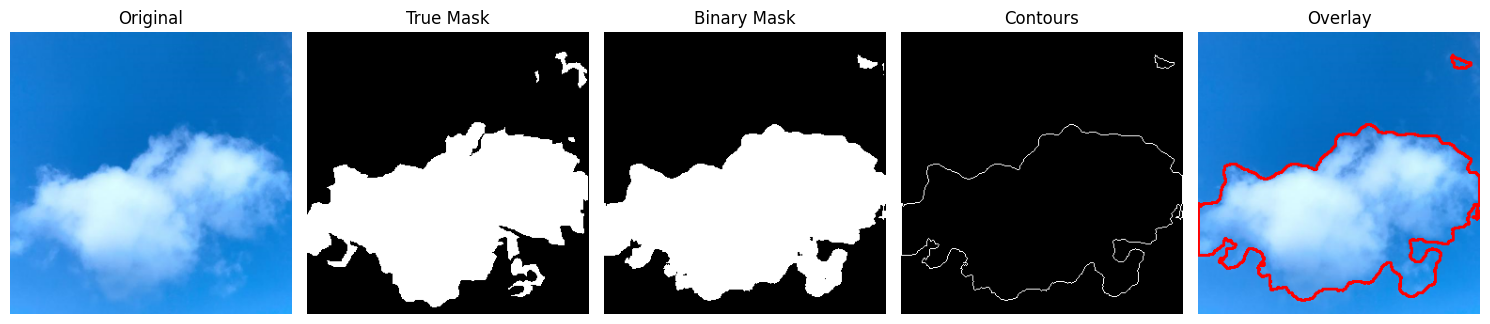

In [25]:
threshold = 0.45

idx = random.randint(0, len(x_test_all) - 1)

image = x_test_all[idx]
true_mask = y_true_all[idx]
pred_mask = y_pred_all[idx]

img = image.copy()
if img.max() <= 1.0:
    img = (img * 255).astype(np.uint8)
else:
    img = img.astype(np.uint8)

binary_pred = (pred_mask > threshold).astype(np.uint8)
binary_cv = (binary_pred.squeeze() * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    binary_cv,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

overlay = img.copy()
cv2.drawContours(overlay, filtered_contours, -1, (255, 0, 0), 2)

contour_img = np.zeros_like(binary_cv)
cv2.drawContours(contour_img, filtered_contours, -1, 255, 1)

plt.figure(figsize=(15, 4))

plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(binary_pred.squeeze(), cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(contour_img, cmap="gray")
plt.title("Contours")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig("single_sample_contour.png", dpi=500)
plt.show()

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
with open('C:/Users/ChaiL/OneDrive - University of Southampton/Final Year Project/cloud_detection_model/TL_cloudsegnet.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\chail\AppData\Local\Temp\tmpilqji_kq\assets


INFO:tensorflow:Assets written to: C:\Users\chail\AppData\Local\Temp\tmpilqji_kq\assets
